## Introduction

This project presents a deep learning approach to stock price prediction using LSTM networks in TensorFlow. The objective is to model time-series data and capture temporal patterns in stock prices to forecast future trends. The workflow includes data preprocessing, feature scaling, model training, and performance evaluation.


## 1. Importing Libraries

In this section, we import the core libraries used in the project, including Pandas and NumPy for data manipulation, Matplotlib and Seaborn for visualization, and TensorFlow for building and training the LSTM model.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os 
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

In [8]:
data = pd.read_csv('all_stocks_5yr.csv', delimiter=',', on_bad_lines='skip')
print(data.shape)
print(data.sample(10))

(619040, 7)
              date    open     high       low   close   volume  Name
615294  2013-03-26   73.11   74.230   72.9800   74.21  1176336   ZBH
261944  2015-06-12   45.43   45.790   45.2400   45.48  5403027   HAL
581299  2017-12-11  113.23  114.441  113.2300  114.32   638444  VRSN
338465  2017-08-25   36.39   37.015   36.2000   36.56  3048311    LB
106162  2014-02-28   39.93   39.985   39.5600   39.66  6653169   CCL
182756  2013-02-25   55.47   55.730   53.9800   54.00  4826320   DVN
614265  2014-02-24   72.87   73.400   72.7401   72.97  1803793   YUM
63919   2017-07-24  191.42  191.420  189.1600  189.16   537722   AVB
394204  2014-01-07  115.13  115.820  114.6500  115.48   941690   MTB
315545  2014-03-26   64.05   64.250   63.1500   63.16   983518   JEC


This dataset contains 619,040 rows and 7 columns representing historical daily stock market data for multiple companies. Each record includes Open, High, Low, Close prices, trading Volume, and the stock ticker (Name). It is a multi-stock time-series dataset spanning several years, making it suitable for financial analysis and predictive modeling tasks such as stock price forecasting, trend analysis, and volatility studies.


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


The dataset is mostly clean with minimal missing values, but requires datetime conversion and proper handling of stock-wise time ordering before machine learning modeling.

In [10]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


## Exploratory Data Analysis

This section presents exploratory data analysis (EDA) of selected stocks by visualizing Open, Close prices and trading Volume across multiple companies. Each stock is filtered individually to preserve its time-series structure, allowing comparison of price movements and market activity over time. The plots help reveal trends, volatility differences, and trading behavior patterns essential for time-series forecasting and machine learning modeling.


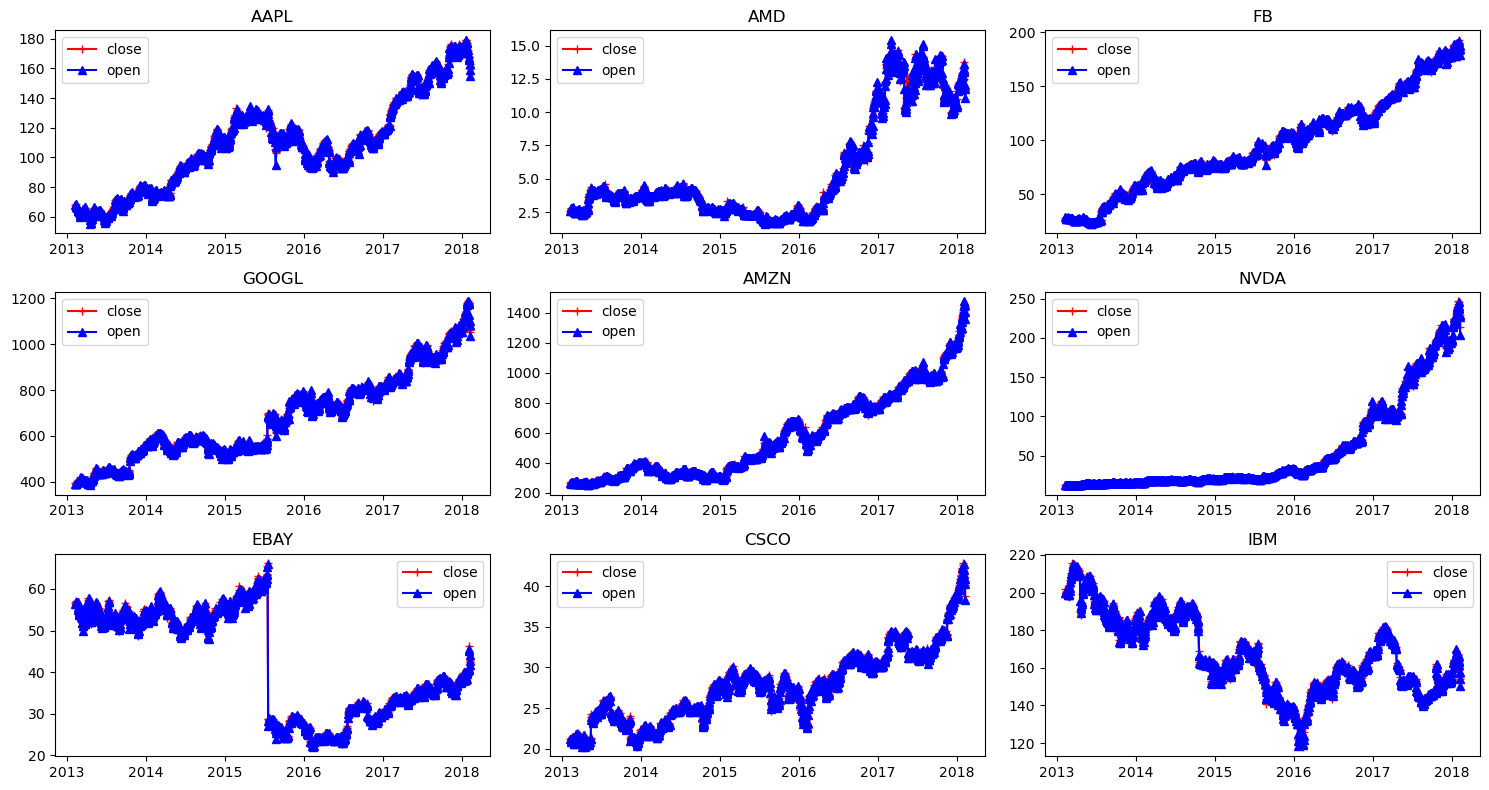

In [15]:
companies = ['AAPL', 'AMD', 'FB', 'GOOGL', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['close'], c="r", label="close", marker="+")
    plt.plot(c['date'], c['open'], c="b", label="open", marker="^")
    plt.title(company)
    plt.legend()
    plt.tight_layout()

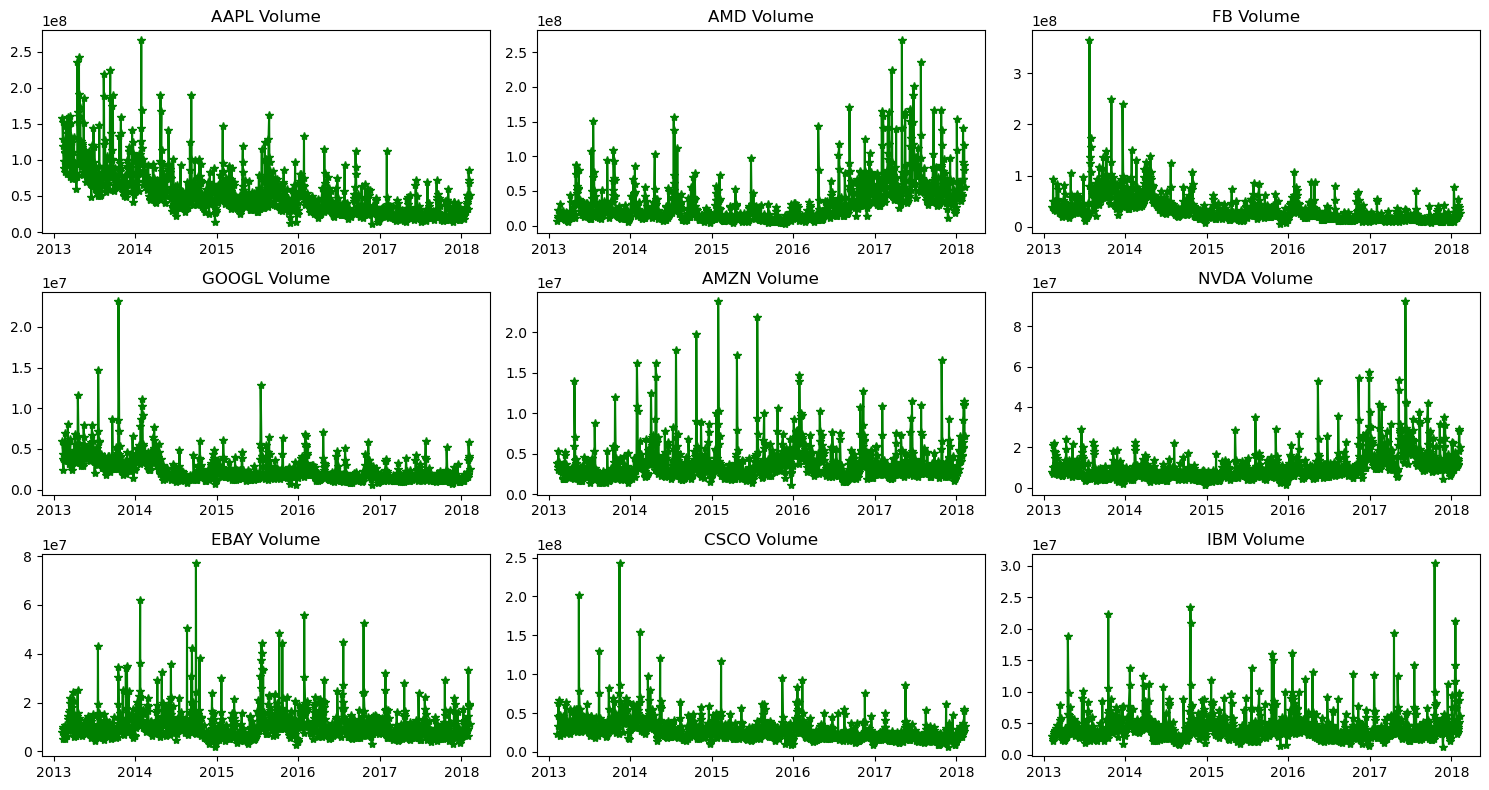

In [18]:
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['volume'], c='green', marker='*')
    plt.title(f"{company} Volume")
    plt.tight_layout()

This section filters Facebook (Meta) stock data from the full dataset and visualizes the closing price trend over time. The goal is to observe historical price movements and identify patterns or trends that can inform time-series analysis and forecasting. A date range filter is applied to focus on a specific period before plotting the stock’s closing prices.


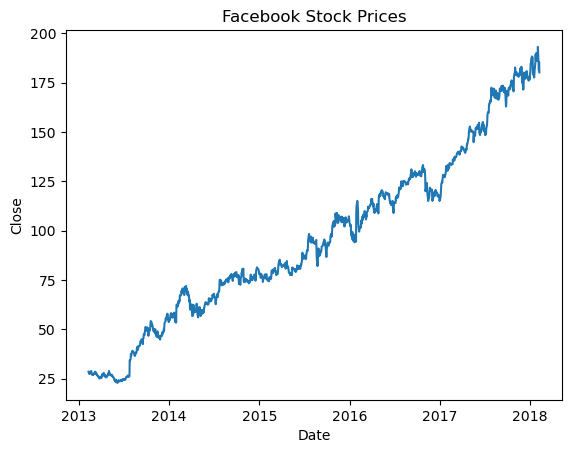

In [20]:
facebook = data[data['Name'] == 'FB']
prediction_range = facebook.loc[(facebook['date'] > datetime(2013,1,1))
    & (facebook['date'] < datetime(2018,1,1))]
plt.plot(facebook['date'], facebook['close'])
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Facebook Stock Prices')
plt.show()

This section extracts the closing price data from the Facebook stock dataset and converts it into a NumPy array for modeling. It then calculates a 95% split point to separate the data into training and testing sets, which is commonly used in time-series forecasting to ensure the model is trained on historical data before evaluating future predictions.


In [21]:
close_data = facebook.filter(['close'])
dataset = close_data.values
training = int(np.ceil(len(dataset) * .95))
print(training)             

1197


## Build LSTM network using TensorFlow

This section scales the stock price data using MinMaxScaler to normalize values between 0 and 1, which improves LSTM model performance. The data is then split into training sequences where each input (x_train) contains 60 previous time steps, and the corresponding output (y_train) is the next value. Finally, the input data is reshaped into a 3D format required for LSTM models: samples, time steps, and features.


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(dataset)

train_data = scaled_data[0:int(training), :]

x_train = []
y_train = []


for i in range(60, len(train_data)):
    x_train.append(train_data[i - 60:i, 0])
    y_train.append(train_data[i, 0])


x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

